# TBX3 and PDK4 Co-expression in ER+ Mature Luminal Cells

Bhat-Nakshatri et al. 2021 identify TBX3 and PDK4 as genes co-expressed with 
estrogen receptor (ESR1) in mature luminal breast epithelial cells, with variable 
expression that stratifies ER+ breast cancers into clinically distinct subtypes. 
This notebook examines TBX3/PDK4 expression within the mature luminal lineage and 
tests their co-expression in ESR1+ cells.

In [1]:
import os
os.environ['NUMBA_NUM_THREADS'] = '64'

import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

sc.settings.verbosity = 1

adata_epi = sc.read_h5ad('checkpoints/adata_epithelial_annotated.h5ad')
print(adata_epi)

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AnnData object with n_obs × n_vars = 12466 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample', 'leiden', 'cell_type', 'lineage'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'lineage_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


## Mature luminal subset — ESR1, TBX3, PDK4 expression by cluster

Expression of ESR1, its pioneer factors (GATA3, FOXA1), TBX3, PDK4, and the mature 
luminal markers XBP1/STC2 is examined across the fine-grained clusters within the 
Mature_Luminal lineage.

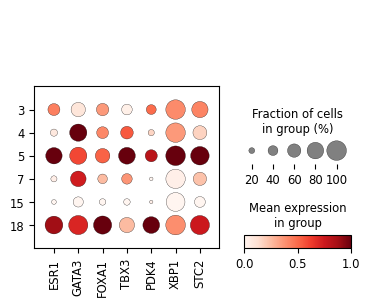

In [2]:
adata_ml = adata_epi[adata_epi.obs['lineage'] == 'Mature_Luminal'].copy()

genes_of_interest = ['ESR1', 'GATA3', 'FOXA1', 'TBX3', 'PDK4', 'XBP1', 'STC2']

sc.pl.dotplot(adata_ml, genes_of_interest, groupby='leiden', use_raw=True, standard_scale='var')

## Cell-level TBX3/PDK4 co-expression in ESR1+ cells

Cells with detectable ESR1 expression are isolated, and TBX3/PDK4 status (positive 
vs low, based on detectable expression) is cross-tabulated to test for association, 
mirroring the ER+/TBX3/PDK4 subclassification reported in the paper.

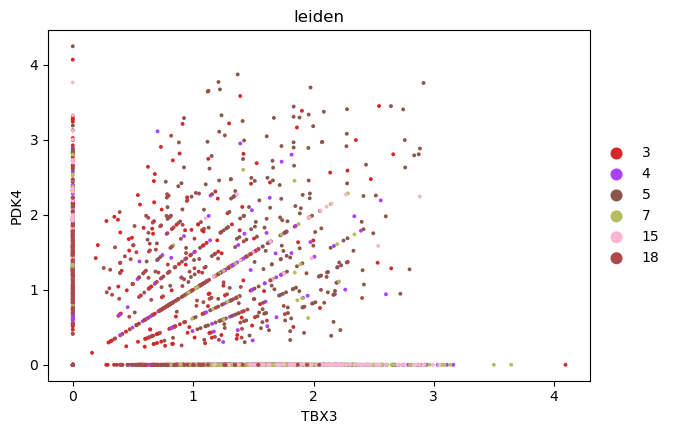

ESR1+ mature luminal cells: 1668 out of 3832
PDK4_status  PDK4+  PDK4low
TBX3_status                
TBX3+          596      495
TBX3low        212      365

Chi-square: 47.63, p-value: 5.14e-12


In [3]:
sc.pl.scatter(adata_ml, x='TBX3', y='PDK4', color='leiden', use_raw=True)

esr1_pos = adata_ml[adata_ml.raw[:, 'ESR1'].X.toarray().flatten() > 0].copy()
print(f"ESR1+ mature luminal cells: {esr1_pos.n_obs} out of {adata_ml.n_obs}")

tbx3_expr = esr1_pos.raw[:, 'TBX3'].X.toarray().flatten()
pdk4_expr = esr1_pos.raw[:, 'PDK4'].X.toarray().flatten()

esr1_pos.obs['TBX3_status'] = np.where(tbx3_expr > 0, 'TBX3+', 'TBX3low')
esr1_pos.obs['PDK4_status'] = np.where(pdk4_expr > 0, 'PDK4+', 'PDK4low')

contingency = pd.crosstab(esr1_pos.obs['TBX3_status'], esr1_pos.obs['PDK4_status'])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: {chi2:.2f}, p-value: {p:.2e}")

## Summary

TBX3 and PDK4 show a statistically significant positive association in ESR1+ mature 
luminal cells, consistent with the paper's finding that these two genes co-vary 
within the ER+ luminal compartment and can be used to further subclassify ER+ breast 
cancers.